# Reading the Data

In [1]:
import pandas as pd
df_matched = pd.read_excel("del7_ADRD_with_map_3new.xlsx")

In [2]:
df_matched

,Unnamed: 0,case_x,study_id,study_enc_id,study_case_id,duration,outcome,del_1,del_8,year-proc,...,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,case_y,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min
0,0,1,100046,6670,6782,182.0,1,1,0,2010,...,0,0,0,0,0,1,0,104,107,3
1,1,1,100058,726497,759592,47.0,1,1,0,2020,...,0,0,0,0,0,1,0,2,111,0
2,2,1,100085,786241,822415,20.0,1,1,0,2020,...,0,0,0,1,0,1,0,0,8,13
3,3,1,100699,285964,300061,14.0,1,1,0,2015,...,0,0,0,1,0,1,1,7,40,2
4,4,1,100836,146596,159718,84.0,1,1,0,2013,...,0,0,0,0,0,1,1,48,59,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,5743,0,588355,548995,574123,78.0,0,0,0,2018,...,0,0,0,0,0,0,0,4,80,11
5725,5744,0,588367,6093,6184,212.0,0,0,0,2010,...,1,0,0,0,0,0,0,49,127,67
5726,5745,0,588385,301929,316499,92.0,0,0,0,2015,...,0,0,0,0,0,0,0,70,41,0
5727,5746,0,588477,55756,58224,25.0,0,0,0,2011,...,0,1,0,0,0,0,0,0,33,0


# Exploratory Data Analysis

In [3]:
df_matched[df_matched["outcome"] != df_matched["del_1"]]

,Unnamed: 0,case_x,study_id,study_enc_id,study_case_id,duration,outcome,del_1,del_8,year-proc,...,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,case_y,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min


In [3]:
suspects = ['anti-parkinsonian', 'antidepressants', 'Dementia', 'Muscle Relaxants', 'Antimuscarinics/Incontinence Meds']
print("suspects unique values:")
for col in suspects:
    print(f"{col}: {df_matched[col].unique()}")

suspects unique values:
anti-parkinsonian: [0]
antidepressants: [0]
Dementia: [0 1]
Muscle Relaxants: [0 1]
Antimuscarinics/Incontinence Meds: [0]


In [4]:
df_matched['ethnicity'].value_counts()

ethnicity
Not Hispanic or Latino    5562
Hispanic or Latino          98
Unknown                     52
Declined                     6
Name: count, dtype: int64

# Data Preprocessing

In [4]:
df_dropped = df_matched.drop(columns=['map_mean', 'outcome','Case','Muscle Relaxants', 'case_x', 'case_y', 'del_8', 'Unnamed: 0', 'case', 'Antimuscarinics/Incontinence Meds', 'asa_class.1', 'age.1', 'anti-parkinsonian', 'antidepressants', 'Respiratory Medications', 'study_id_case', 'study_enc_id_case', 'study_case_id_case'], errors="ignore")
df_dropped

,study_id,study_enc_id,study_case_id,duration,del_1,year-proc,sex,race,ethnicity,age,...,GYN,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min
0,100046,6670,6782,182.0,1,2010,F,White,Not Hispanic or Latino,84,...,0,0,0,0,0,0,0,104,107,3
1,100058,726497,759592,47.0,1,2020,M,White,Not Hispanic or Latino,83,...,0,0,0,0,0,0,0,2,111,0
2,100085,786241,822415,20.0,1,2020,F,Black or African American,Not Hispanic or Latino,64,...,0,0,0,0,1,0,0,0,8,13
3,100699,285964,300061,14.0,1,2015,F,Black or African American,Not Hispanic or Latino,81,...,0,0,0,0,1,0,1,7,40,2
4,100836,146596,159718,84.0,1,2013,F,Black or African American,Not Hispanic or Latino,71,...,0,0,0,0,0,0,1,48,59,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,588355,548995,574123,78.0,0,2018,F,White,Not Hispanic or Latino,63,...,0,0,0,0,0,0,0,4,80,11
5725,588367,6093,6184,212.0,0,2010,M,White,Not Hispanic or Latino,60,...,0,1,0,0,0,0,0,49,127,67
5726,588385,301929,316499,92.0,0,2015,M,Black or African American,Not Hispanic or Latino,70,...,0,0,0,0,0,0,0,70,41,0
5727,588477,55756,58224,25.0,0,2011,M,Black or African American,Not Hispanic or Latino,48,...,0,0,1,0,0,0,0,0,33,0


In [5]:
pd.set_option('display.max_columns', None)

In [7]:
df_dropped

,study_id,study_enc_id,study_case_id,duration,del_1,year-proc,sex,race,ethnicity,age,asa_class,asa1,asa1e,asa2,asa2e,asa3,asa3e,asa4,asa4e,asa5,asa5e,asa6,asa6e,CCI,cisatracurium,hydromorphone,lorazepam,midazolam,sufentanil,alfentanil,dexmedetomidine,etomidate,fentanyl,ketamine,methadone,meperidine,morphine,propofol,remifentanil,rocuronium,succinylcholine,vecuronium,diazepam,map_min,map_max,esmolol,hydralazine,labetalol,metoprolol,nicardipine,nitroprusside,enalapril,epinephrine,norepinephrine,phenylephrine,ephedrine,vasopressin,dopamine,milrinone,dobutamine,SE,Anemia,CKD,COPD,Cancer,Cancer METS,Cardiac arrhythmia,Cerebral Vascular Dz,Chr Dialysis,Chr ETOH,Chr heart failure,Diabetes,Disease of the AORTA,Drug Abuse,HTN,Heart valve dz,Hemiplegia/Paraplegia,Ischemic heart dz,LIVER DZ,Obesity,Peripheral vascular disease,Psychiatric Disorders,Pulmonaru Vasular Dz,Resp Failure,Transplanted Organ,anti histaminics,Antispasmotics,sedatives,antihypertensives,Gastrointestinal Agents,opioids and NSAIDS,psychoactive and anticonvulsant,steroids,antipsychotics,anti-arrhythmics,antibiotics,total_mac_hrs,inhal_anesthesia,General Surgery,Vascular,Orthopedics,Thoracic,Neurosurgery,GYN,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min
0,100046,6670,6782,182.0,1,2010,F,White,Not Hispanic or Latino,84,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,51.33,110.33,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,2.503006,1,0,0,1,0,0,0,0,0,0,0,0,0,104,107,3
1,100058,726497,759592,47.0,1,2020,M,White,Not Hispanic or Latino,83,3,0,0,0,0,1,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,61.33,92.67,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,1,1,0,1,0,0,1,1,1,0,1,0,1,1,1,1,1,0,0,1,0,0,0,3,0,0,0,0,0,1.449018,1,0,0,1,0,0,0,0,0,0,0,0,0,2,111,0
2,100085,786241,822415,20.0,1,2020,F,Black or African American,Not Hispanic or Latino,64,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,88.00,124.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,8,13
3,100699,285964,300061,14.0,1,2015,F,Black or African American,Not Hispanic or Latino,81,3,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,48.67,95.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,1,7,40,2
4,100836,146596,159718,84.0,1,2013,F,Black or African American,Not Hispanic or Latino,71,4,0,0,0,0,0,0,1,0,0,0,0,0,7,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,50.33,88.67,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,1,1,0,0,1,1,0,1,0,1,1,1,1,0,0,0,0,0,1,0,3,0,0,0,0,0,1.705932,1,0,1,0,0,0,0,0,0,0,0,0,1,48,59,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,588355,548995,574123,78.0,0,2018,F,White,Not Hispanic or Latino,63,3,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,60.00,116.00,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.681729,1,1,0,0,0,0,0,0,0,0,0,0,0,4,80,11
5725,588367,6093,6184,212.0,0,2010,M,White,Not Hispanic or Latino,60,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,34.67,171.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,0,0,0,0,0,0.232062,1,0,0,0,0,0,0,1,0,0,0,0,0,49,127,67
5726,588385,301929,316499,92.0,0,2015,M,Black or African American,Not Hispanic or Latino,70,3,0,0,0,0,1,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,56.33,87.

## Medication Class Binarization (Presence/Absence Encoding)

In [7]:
mask_cols = [
    'anti histaminics', 'Antispasmotics', 'sedatives',
    'antihypertensives', 'Gastrointestinal Agents',
    'opioids and NSAIDS', 'psychoactive and anticonvulsant ',
    'steroids', 'anti-arrhythmics', 'antibiotics'
]

# Keep originals with suffix "_orig"
for col in mask_cols:
    df_dropped[col + "_orig"] = df_dropped[col]
    df_dropped[col] = (df_dropped[col] > 0).astype(int)   

In [8]:
# 1) Clean column names (strip, lower, replace spaces)
df_dropped.columns = (
    df_dropped.columns
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
)

In [9]:
df_dropped

,study_id,study_enc_id,study_case_id,duration,del_1,year-proc,sex,race,ethnicity,age,asa_class,asa1,asa1e,asa2,asa2e,asa3,asa3e,asa4,asa4e,asa5,asa5e,asa6,asa6e,CCI,cisatracurium,hydromorphone,lorazepam,midazolam,sufentanil,alfentanil,dexmedetomidine,etomidate,fentanyl,ketamine,methadone,meperidine,morphine,propofol,remifentanil,rocuronium,succinylcholine,vecuronium,diazepam,map_min,map_max,esmolol,hydralazine,labetalol,metoprolol,nicardipine,nitroprusside,enalapril,epinephrine,norepinephrine,phenylephrine,ephedrine,vasopressin,dopamine,milrinone,dobutamine,SE,Anemia,CKD,COPD,Cancer,Cancer METS,Cardiac arrhythmia,Cerebral Vascular Dz,Chr Dialysis,Chr ETOH,Chr heart failure,Diabetes,Disease of the AORTA,Drug Abuse,HTN,Heart valve dz,Hemiplegia/Paraplegia,Ischemic heart dz,LIVER DZ,Obesity,Peripheral vascular disease,Psychiatric Disorders,Pulmonaru Vasular Dz,Resp Failure,Transplanted Organ,anti histaminics,Antispasmotics,sedatives,antihypertensives,Gastrointestinal Agents,opioids and NSAIDS,psychoactive and anticonvulsant,steroids,antipsychotics,anti-arrhythmics,antibiotics,total_mac_hrs,inhal_anesthesia,General Surgery,Vascular,Orthopedics,Thoracic,Neurosurgery,GYN,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min,anti histaminics_orig,Antispasmotics_orig,sedatives_orig,antihypertensives_orig,Gastrointestinal Agents_orig,opioids and NSAIDS_orig,psychoactive and anticonvulsant _orig,steroids_orig,anti-arrhythmics_orig,antibiotics_orig
0,100046,6670,6782,182.0,1,2010,F,White,Not Hispanic or Latino,84,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,51.33,110.33,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,2.503006,1,0,0,1,0,0,0,0,0,0,0,0,0,104,107,3,0,0,1,0,1,1,0,0,0,0
1,100058,726497,759592,47.0,1,2020,M,White,Not Hispanic or Latino,83,3,0,0,0,0,1,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,61.33,92.67,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,1,1,0,1,0,0,1,1,1,0,1,0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,1.449018,1,0,0,1,0,0,0,0,0,0,0,0,0,2,111,0,0,1,0,0,0,3,0,0,0,0
2,100085,786241,822415,20.0,1,2020,F,Black or African American,Not Hispanic or Latino,64,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,88.00,124.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,8,13,0,0,0,0,0,0,0,0,0,0
3,100699,285964,300061,14.0,1,2015,F,Black or African American,Not Hispanic or Latino,81,3,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,48.67,95.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,1,7,40,2,0,0,0,0,0,0,0,0,0,0
4,100836,146596,159718,84.0,1,2013,F,Black or African American,Not Hispanic or Latino,71,4,0,0,0,0,0,0,1,0,0,0,0,0,7,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,50.33,88.67,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,1,1,0,0,1,1,0,1,0,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1.705932,1,0,1,0,0,0,0,0,0,0,0,0,1,48,59,0,0,0,0,1,0,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,588355,548995,574123,78.0,0,2018,F,White,Not Hispanic or Latino,63,3,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,60.00,116.00,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.681729,1,1,0,0,0,0,0,0,0,0,0,0,0,4,80,11,0,0,0,0,0,1,0,0,0,0
5725,588367,6093,6184,212.0,0,2010,M,White,Not Hispanic or Latino,60,3,0,0,0,0

## Feature Engineering for ASA Class and Emergency Status

In [10]:
# --- Step 1: Drop "_orig" columns ---
df_mod = df_dropped.loc[:, ~df_dropped.columns.str.endswith("_orig")].copy()
print(f"Dropped _orig columns. Remaining columns: {df_mod.shape[1]}")

# --- Step 2: Create ASA numeric and emergency flag ---
# ASA class numeric: extract from asa_class (if present)
if "asa_class" in df_mod.columns:
    # Coerce text to numeric safely
    df_mod["asa_class_num"] = (
        df_mod["asa_class"]
        .astype(str)
        .str.extract(r"(\d)")
        .astype(float)
    )

# Emergency flag: 1 if any of the ASA_emergency variants (asa1e–asa6e) are 1
asa_emerg_cols = [c for c in df_mod.columns if c.lower().startswith("asa") and c.lower().endswith("e")]
df_mod["asa_emerg_flag"] = df_mod[asa_emerg_cols].max(axis=1) if asa_emerg_cols else 0

# --- Step 3: Drop individual ASA one-hot columns (asa1–asa6 and asa1e–asa6e) ---
asa_cols_to_drop = [c for c in df_mod.columns if c.lower().startswith("asa") and (c.lower().endswith(tuple(str(i) for i in range(1, 7))) or c.lower().endswith(tuple(f"{i}e" for i in range(1, 7))))]
df_mod.drop(columns=asa_cols_to_drop, inplace=True, errors="ignore")

print(f"Created asa_class_num + asa_emerg_flag and dropped {len(asa_cols_to_drop)} ASA dummies.")
print(df_mod[["asa_class", "asa_class_num", "asa_emerg_flag"]].head())


Dropped _orig columns. Remaining columns: 113
Created asa_class_num + asa_emerg_flag and dropped 12 ASA dummies.
  asa_class  asa_class_num  asa_emerg_flag
0         3            3.0               0
1         3            3.0               0
2         3            3.0               0
3         3            3.0               0
4         4            4.0               0


In [11]:
print(df_mod[["asa_class", "asa_class_num", "asa_emerg_flag"]].head(20))

   asa_class  asa_class_num  asa_emerg_flag
0          3            3.0               0
1          3            3.0               0
2          3            3.0               0
3          3            3.0               0
4          4            4.0               0
5          3            3.0               0
6          4            4.0               0
7          4            4.0               0
8         3E            3.0               1
9         4E            4.0               1
10         3            3.0               0
11        4E            4.0               1
12        4E            4.0               1
13        5E            5.0               1
14        5E            5.0               1
15        4E            4.0               1
16         3            3.0               0
17        4E            4.0               1
18         3            3.0               0
19         3            3.0               0


In [12]:
df_mod

,study_id,study_enc_id,study_case_id,duration,del_1,year-proc,sex,race,ethnicity,age,asa_class,CCI,cisatracurium,hydromorphone,lorazepam,midazolam,sufentanil,alfentanil,dexmedetomidine,etomidate,fentanyl,ketamine,methadone,meperidine,morphine,propofol,remifentanil,rocuronium,succinylcholine,vecuronium,diazepam,map_min,map_max,esmolol,hydralazine,labetalol,metoprolol,nicardipine,nitroprusside,enalapril,epinephrine,norepinephrine,phenylephrine,ephedrine,vasopressin,dopamine,milrinone,dobutamine,SE,Anemia,CKD,COPD,Cancer,Cancer METS,Cardiac arrhythmia,Cerebral Vascular Dz,Chr Dialysis,Chr ETOH,Chr heart failure,Diabetes,Disease of the AORTA,Drug Abuse,HTN,Heart valve dz,Hemiplegia/Paraplegia,Ischemic heart dz,LIVER DZ,Obesity,Peripheral vascular disease,Psychiatric Disorders,Pulmonaru Vasular Dz,Resp Failure,Transplanted Organ,anti histaminics,Antispasmotics,sedatives,antihypertensives,Gastrointestinal Agents,opioids and NSAIDS,psychoactive and anticonvulsant,steroids,antipsychotics,anti-arrhythmics,antibiotics,total_mac_hrs,inhal_anesthesia,General Surgery,Vascular,Orthopedics,Thoracic,Neurosurgery,GYN,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min,asa_class_num,asa_emerg_flag
0,100046,6670,6782,182.0,1,2010,F,White,Not Hispanic or Latino,84,3,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,51.33,110.33,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,2.503006,1,0,0,1,0,0,0,0,0,0,0,0,0,104,107,3,3.0,0
1,100058,726497,759592,47.0,1,2020,M,White,Not Hispanic or Latino,83,3,6,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,61.33,92.67,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,1,1,0,1,0,0,1,1,1,0,1,0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,1.449018,1,0,0,1,0,0,0,0,0,0,0,0,0,2,111,0,3.0,0
2,100085,786241,822415,20.0,1,2020,F,Black or African American,Not Hispanic or Latino,64,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,88.00,124.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,8,13,3.0,0
3,100699,285964,300061,14.0,1,2015,F,Black or African American,Not Hispanic or Latino,81,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,48.67,95.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,1,7,40,2,3.0,0
4,100836,146596,159718,84.0,1,2013,F,Black or African American,Not Hispanic or Latino,71,4,7,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,50.33,88.67,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,1,1,0,0,1,1,0,1,0,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1.705932,1,0,1,0,0,0,0,0,0,0,0,0,1,48,59,0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,588355,548995,574123,78.0,0,2018,F,White,Not Hispanic or Latino,63,3,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,60.00,116.00,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.681729,1,1,0,0,0,0,0,0,0,0,0,0,0,4,80,11,3.0,0
5725,588367,6093,6184,212.0,0,2010,M,White,Not Hispanic or Latino,60,3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,34.67,171.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.232062,1,0,0,0,0,0,0,1,0,0,0,0,0,49,127,67,3.0,0
5726,588385,301929,316499,92.0,0,2015,M,Black or African American,Not Hispanic or Latino,70,3,4,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,56.33,87.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,1,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.000000,0,0,1,0,0,0,0,0,0,0,0,0,0,70,41,0,3.0,0
5727,588477,55756,58224,25.0,0,2011,M,Black or African American,Not Hispa

## Phik-Based Feature Correlation Screening

In [13]:
# --- 1. Drop redundant column ---
df_phik = df_mod.drop(columns=["asa_class"], errors="ignore").copy()

# --- 2. Import and compute Phik correlation matrix ---
from phik import phik_matrix
from phik.report import plot_correlation_matrix
import numpy as np, pandas as pd

# Numeric columns (for better binning)
interval_cols = df_phik.select_dtypes(include=["number"]).columns.tolist()

# Compute Phik correlation matrix
phik_mat = phik_matrix(df_phik, interval_cols=interval_cols)

# --- 3. Flatten into long-form pairs ---
np.fill_diagonal(phik_mat.values, np.nan)
mask_upper = np.triu(np.ones_like(phik_mat, dtype=bool), k=1)
pairs = (
    phik_mat.where(mask_upper)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "col1", "level_1": "col2", 0: "phik"})
            .sort_values("phik", ascending=False)
)

# --- 4. View highly correlated pairs (>|0.8|) ---
high_pairs = pairs.loc[pairs["phik"] > 0.8].reset_index(drop=True)
print("Highly correlated pairs (>|0.8|):")
print(high_pairs.head(50).to_string(index=False))

# Optional visualization (good for overview)
# plot_correlation_matrix(phik_mat.values, x_labels=phik_mat.columns, y_labels=phik_mat.index, vmin=0.5, vmax=1.0)


Highly correlated pairs (>|0.8|):
         col1                            col2     phik
 study_enc_id                   study_case_id 0.999921
     ketamine psychoactive and anticonvulsant 0.998867
    midazolam                       sedatives 0.996790
study_case_id                       year-proc 0.990390
 study_enc_id                       year-proc 0.990062
     fentanyl              opioids and NSAIDS 0.975181
          CKD                    Chr Dialysis 0.971636
   metoprolol               antihypertensives 0.948791
     Chr ETOH                      Drug Abuse 0.839514


In [14]:
# --- Drop redundant high-correlation features (based on expert review) ---
drop_cols = [
    "psychoactive and anticonvulsant",
    "sedatives",
    "Chr Dialysis",
    "opioids and NSAIDS",
    "antihypertensives",
    "Drug Abuse"
]

df_mod = df_mod.drop(columns=drop_cols, errors="ignore")

print(f"Dropped {len(drop_cols)} highly correlated columns:")
print(drop_cols)
print(f"\nRemaining columns: {df_mod.shape[1]}")


Dropped 6 highly correlated columns:
['psychoactive and anticonvulsant', 'sedatives', 'Chr Dialysis', 'opioids and NSAIDS', 'antihypertensives', 'Drug Abuse']

Remaining columns: 97


In [10]:
unique_names = df_mod['ethnicity'].unique()
print(unique_names)

['Not Hispanic or Latino' 'Unknown' nan 'Hispanic or Latino' 'Declined']


In [19]:
print(df_mod.columns.tolist())


['study_id', 'study_enc_id', 'study_case_id', 'duration', 'del_1', 'year-proc', 'sex', 'race', 'ethnicity', 'age', 'asa_class', 'CCI', 'cisatracurium', 'hydromorphone', 'lorazepam', 'midazolam', 'sufentanil', 'alfentanil', 'dexmedetomidine', 'etomidate', 'fentanyl', 'ketamine', 'methadone', 'meperidine', 'morphine', 'propofol', 'remifentanil', 'rocuronium', 'succinylcholine', 'vecuronium', 'diazepam', 'map_min', 'map_max', 'esmolol', 'hydralazine', 'labetalol', 'metoprolol', 'nicardipine', 'nitroprusside', 'enalapril', 'epinephrine', 'norepinephrine', 'phenylephrine', 'ephedrine', 'vasopressin', 'dopamine', 'milrinone', 'dobutamine', 'SE', 'Anemia', 'CKD', 'COPD', 'Cancer', 'Cancer METS', 'Cardiac arrhythmia', 'Cerebral Vascular Dz', 'Chr ETOH', 'Chr heart failure', 'Diabetes', 'Disease of the AORTA', 'HTN', 'Heart valve dz', 'Hemiplegia/Paraplegia', 'Ischemic heart dz', 'LIVER DZ', 'Obesity', 'Peripheral vascular disease', 'Psychiatric Disorders', 'Pulmonaru Vasular Dz', 'Resp Failure

## Missing values check and imputation

In [15]:
# --- Missing value summary for df_dropped ---
import pandas as pd

missing_summary = (
    df_mod.isna()
    .sum()
    .to_frame("n_missing")
    .assign(pct_missing=lambda d: 100 * d["n_missing"] / len(df_mod))
    .query("n_missing > 0")  # only columns with missing values
    .sort_values("pct_missing", ascending=False)
)

print("=== Missing value summary (only columns with >0 missing) ===")
display(missing_summary.head(30))  # show top 30 for quick scan
print(f"\nTotal columns with missing values: {missing_summary.shape[0]}")
print(f"Total rows: {len(df_mod)}")


=== Missing value summary (only columns with >0 missing) ===


,n_missing,pct_missing
ethnicity,30,0.523652
asa_class,1,0.017455
asa_class_num,1,0.017455



Total columns with missing values: 3
Total rows: 5729


In [16]:
# --- Handle missing values in df_mod ---
df_mod = df_mod.copy()

# 1) Fill missing ethnicity with 'Unknown'
df_mod["ethnicity"] = df_mod["ethnicity"].fillna("Unknown")

# 2) Impute ASA class and ASA class_num
if "asa_class" in df_mod.columns:
    mode_asa = df_mod["asa_class"].mode(dropna=True)[0]
    df_mod["asa_class"] = df_mod["asa_class"].fillna(mode_asa)

if "asa_class_num" in df_mod.columns:
    median_asa_num = df_mod["asa_class_num"].median()
    df_mod["asa_class_num"] = df_mod["asa_class_num"].fillna(median_asa_num)

# --- Quick verification ---
print("Remaining missing values after imputation:")
print(df_mod.isna().sum().loc[lambda x: x > 0])


Remaining missing values after imputation:
Series([], dtype: int64)


In [17]:
df_mod

,study_id,study_enc_id,study_case_id,duration,del_1,year-proc,sex,race,ethnicity,age,asa_class,CCI,cisatracurium,hydromorphone,lorazepam,midazolam,sufentanil,alfentanil,dexmedetomidine,etomidate,fentanyl,ketamine,methadone,meperidine,morphine,propofol,remifentanil,rocuronium,succinylcholine,vecuronium,diazepam,map_mean,map_min,map_max,esmolol,hydralazine,labetalol,metoprolol,nicardipine,nitroprusside,enalapril,epinephrine,norepinephrine,phenylephrine,ephedrine,vasopressin,dopamine,milrinone,dobutamine,SE,Anemia,CKD,COPD,Cancer,Cancer METS,Cardiac arrhythmia,Cerebral Vascular Dz,Chr ETOH,Chr heart failure,Diabetes,Disease of the AORTA,HTN,Heart valve dz,Hemiplegia/Paraplegia,Ischemic heart dz,LIVER DZ,Obesity,Peripheral vascular disease,Psychiatric Disorders,Pulmonaru Vasular Dz,Resp Failure,Transplanted Organ,anti histaminics,Antispasmotics,Gastrointestinal Agents,steroids,antipsychotics,anti-arrhythmics,antibiotics,total_mac_hrs,inhal_anesthesia,General Surgery,Vascular,Orthopedics,Thoracic,Neurosurgery,GYN,GU,ENT,EP/PACEMAKER,GI-NORA,EYE,Dementia,map_lt_65_min,map_65_95_min,map_gt_95_min,asa_class_num,asa_emerg_flag
0,100046,6670,6782,182.0,1,2010,F,White,Not Hispanic or Latino,84,3,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,66.490000,51.33,110.33,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.503006,1,0,0,1,0,0,0,0,0,0,0,0,0,104,107,3,3.0,0
1,100058,726497,759592,47.0,1,2020,M,White,Not Hispanic or Latino,83,3,6,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,78.325000,61.33,92.67,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,1,0,1,0,0,1,1,0,1,0,1,1,1,1,1,0,0,1,0,0,0,0,0,1.449018,1,0,0,1,0,0,0,0,0,0,0,0,0,2,111,0,3.0,0
2,100085,786241,822415,20.0,1,2020,F,Black or African American,Not Hispanic or Latino,64,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,96.951429,88.00,124.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,8,13,3.0,0
3,100699,285964,300061,14.0,1,2015,F,Black or African American,Not Hispanic or Latino,81,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,81.124792,48.67,95.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,1,7,40,2,3.0,0
4,100836,146596,159718,84.0,1,2013,F,Black or African American,Not Hispanic or Latino,71,4,7,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,67.629167,50.33,88.67,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,1,1,0,1,1,0,1,1,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,1.705932,1,0,1,0,0,0,0,0,0,0,0,0,1,48,59,0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,588355,548995,574123,78.0,0,2018,F,White,Not Hispanic or Latino,63,3,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,81.458750,60.00,116.00,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1.681729,1,1,0,0,0,0,0,0,0,0,0,0,0,4,80,11,3.0,0
5725,588367,6093,6184,212.0,0,2010,M,White,Not Hispanic or Latino,60,3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,87.423835,34.67,171.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.232062,1,0,0,0,0,0,0,1,0,0,0,0,0,49,127,67,3.0,0
5726,588385,301929,316499,92.0,0,2015,M,Black or African American,Not Hispanic or Latino,70,3,4,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,65.406087,56.33,87.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,1,0,0,0,0,0,0,0,0,0,0,70,41,0,3.0,0
5727,588477,55756,58224,25.0,0,2011,M,Black or African American,Not Hispanic or Latino,48,2,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,76.642143,67.00,89.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

# Feature Schema Definition for Reproducible Modeling

In [17]:
# --- Build & save feature schema from df_mod (final) ---
import json, numpy as np, pandas as pd
from pathlib import Path

TARGET = "del_1"

# Exclude IDs & admin columns from features, but keep them in df_mod for CV grouping
ID_COLS = ["study_id", "study_enc_id", "study_case_id"]
ADMIN_COLS = ["year-proc", "asa_class"]  # asa_class_num stays as continuous; raw asa_class is redundant
EXCLUDE = [TARGET] + ID_COLS + ADMIN_COLS

df = df_mod.copy()

# 1) Constants (<=1 unique non-null)
constant_cols = (
    df.drop(columns=EXCLUDE, errors="ignore")
      .nunique(dropna=True)
      .pipe(lambda s: s[s <= 1].index.tolist())
)

# 2) Split by dtype
num_like = df.select_dtypes(include=[np.number, "boolean", "bool"]) \
             .drop(columns=EXCLUDE + constant_cols, errors="ignore")
obj_like = df.select_dtypes(include=["object", "category"]) \
             .drop(columns=EXCLUDE + constant_cols, errors="ignore")

# 3) Detect strict 0/1 binaries among numerics
def is_binary(series: pd.Series) -> bool:
    vals = pd.Series(series).dropna().unique()
    return len(vals) > 0 and set(vals).issubset({0, 1})

binary_cols = [c for c in num_like.columns if is_binary(num_like[c])]
continuous_cols = sorted(set(num_like.columns) - set(binary_cols))
categorical_cols = sorted(obj_like.columns.tolist())

# 4) Enforce ASA design explicitly (keep numeric; flag emergency as binary)
if "asa_class_num" in df.columns:
    if "asa_class_num" in binary_cols:   binary_cols.remove("asa_class_num")
    if "asa_class_num" not in continuous_cols and "asa_class_num" not in constant_cols:
        continuous_cols.append("asa_class_num")

if "asa_emerg_flag" in df.columns and is_binary(df["asa_emerg_flag"]):
    if "asa_emerg_flag" in continuous_cols: continuous_cols.remove("asa_emerg_flag")
    if "asa_emerg_flag" not in binary_cols and "asa_emerg_flag" not in constant_cols:
        binary_cols.append("asa_emerg_flag")

# 5) Final feature list (exclude target, IDs, admin, constants)
feature_list = [c for c in df.columns if c not in set(EXCLUDE + constant_cols)]

# Ensure mutual exclusivity across buckets (priority: categorical > binary > continuous)
seen = set(); final_cats, final_bins, final_conts = [], [], []
for c in sorted(categorical_cols):
    if c in feature_list and c not in seen: final_cats.append(c); seen.add(c)
for c in sorted(binary_cols):
    if c in feature_list and c not in seen: final_bins.append(c); seen.add(c)
for c in sorted(continuous_cols):
    if c in feature_list and c not in seen: final_conts.append(c); seen.add(c)

# Ordered feature list (optional; your choice)
feature_list = final_conts + final_cats + final_bins

# 6) Label stats
label_stats = {TARGET: float(pd.Series(df[TARGET]).mean())}

# 7) Save schema
schema = {
    "target": TARGET,
    "aux_outcomes": [],
    "binary_cols": sorted(final_bins),
    "continuous_cols": sorted(final_conts),
    "categorical_cols": sorted(final_cats),
    "constant_cols": sorted(constant_cols),
    "feature_list": feature_list,
    "dtypes": {c: str(df[c].dtype) for c in feature_list},
    "label_stats": label_stats,
    "exclude_cols": EXCLUDE,        # helpful breadcrumb
    "id_cols": ID_COLS,             # for grouping later
}

Path("artifacts").mkdir(exist_ok=True)
with open("artifacts/feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Saved → artifacts/feature_schema.json")
print(f"Counts → continuous={len(schema['continuous_cols'])}, categorical={len(schema['categorical_cols'])}, binary={len(schema['binary_cols'])}, constants={len(schema['constant_cols'])}")
print("Categoricals:", schema["categorical_cols"])
print("Target prevalence:", f"{schema['label_stats'][TARGET]:.3f}")
print("Excluded (not modeled):", EXCLUDE)


Saved → artifacts/feature_schema.json
Counts → continuous=10, categorical=3, binary=78, constants=0
Categoricals: ['ethnicity', 'race', 'sex']
Target prevalence: 0.500
Excluded (not modeled): ['del_1', 'study_id', 'study_enc_id', 'study_case_id', 'year-proc', 'asa_class']


In [19]:
continuous_cols

['CCI',
 'age',
 'asa_class_num',
 'duration',
 'map_65_95_min',
 'map_gt_95_min',
 'map_lt_65_min',
 'map_max',
 'map_min',
 'total_mac_hrs']

In [20]:
binary_cols

['cisatracurium',
 'hydromorphone',
 'lorazepam',
 'midazolam',
 'sufentanil',
 'alfentanil',
 'dexmedetomidine',
 'etomidate',
 'fentanyl',
 'ketamine',
 'methadone',
 'meperidine',
 'morphine',
 'propofol',
 'remifentanil',
 'rocuronium',
 'succinylcholine',
 'vecuronium',
 'diazepam',
 'esmolol',
 'hydralazine',
 'labetalol',
 'metoprolol',
 'nicardipine',
 'nitroprusside',
 'enalapril',
 'epinephrine',
 'norepinephrine',
 'phenylephrine',
 'ephedrine',
 'vasopressin',
 'dopamine',
 'milrinone',
 'dobutamine',
 'SE',
 'Anemia',
 'CKD',
 'COPD',
 'Cancer',
 'Cancer METS',
 'Cardiac arrhythmia',
 'Cerebral Vascular Dz',
 'Chr ETOH',
 'Chr heart failure',
 'Diabetes',
 'Disease of the AORTA',
 'HTN',
 'Heart valve dz',
 'Hemiplegia/Paraplegia',
 'Ischemic heart dz',
 'LIVER DZ',
 'Obesity',
 'Peripheral vascular disease',
 'Psychiatric Disorders',
 'Pulmonaru Vasular Dz',
 'Resp Failure',
 'Transplanted Organ',
 'anti histaminics',
 'Antispasmotics',
 'Gastrointestinal Agents',
 'stero

In [21]:
categorical_cols

['ethnicity', 'race', 'sex']

# Unfitted Feature Preprocessing for Cross-Validated Modeling

In [18]:
# A) Build & save UNFITTED preprocessor (no leakage, no model)

import json
import joblib
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# 0) Load schema produced earlier
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)

TARGET            = schema["target"]
continuous_cols   = schema["continuous_cols"]
categorical_cols  = schema["categorical_cols"]
binary_cols       = schema["binary_cols"]
EXCLUDED          = schema.get("exclude_cols", [])
ID_COLS           = schema.get("id_cols", ["study_id", "study_enc_id", "study_case_id"])

# 1) Resolve columns actually present in df_mod (guard against drift)
present_cont = [c for c in continuous_cols  if c in df_mod.columns]
present_cat  = [c for c in categorical_cols if c in df_mod.columns]
present_bin  = [c for c in binary_cols      if c in df_mod.columns]

# Safety: ensure excluded + target are not in any present_* lists
ban = set(EXCLUDED + [TARGET])
present_cont = [c for c in present_cont if c not in ban]
present_cat  = [c for c in present_cat  if c not in ban]
present_bin  = [c for c in present_bin  if c not in ban]

# 2) Define unfitted transformers
try:
    # Newer sklearn (>=1.2)
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    # Older sklearn
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

cont_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  RobustScaler()),
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    ohe),
])

bin_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])

# 3) ColumnTransformer (UNFITTED) - no fit/transform here
preprocessor = ColumnTransformer(
    transformers=[
        ("cont", cont_pipe, present_cont),
        ("cat",  cat_pipe,  present_cat),
        ("bin",  bin_pipe,  present_bin),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# 4) Save the unfitted preprocessor and a spec for reproducibility
Path("artifacts").mkdir(exist_ok=True)
joblib.dump(preprocessor, "artifacts/preprocessor_unfitted.joblib")

spec = {
    "target": TARGET,
    "excluded": EXCLUDED,
    "id_cols": ID_COLS,
    "present_cont": present_cont,
    "present_cat": present_cat,
    "present_bin": present_bin,
}
with open("artifacts/preprocessor_spec.json", "w") as f:
    json.dump(spec, f, indent=2)

print("Saved → artifacts/preprocessor_unfitted.joblib")
print("Spec   → artifacts/preprocessor_spec.json")
print(f"Blocks → continuous={len(present_cont)}, categorical={len(present_cat)}, binary={len(present_bin)}")
print("Not modeled (kept only for grouping/metadata):", EXCLUDED)


Saved → artifacts/preprocessor_unfitted.joblib
Spec   → artifacts/preprocessor_spec.json
Blocks → continuous=10, categorical=3, binary=78
Not modeled (kept only for grouping/metadata): ['del_1', 'study_id', 'study_enc_id', 'study_case_id', 'year-proc', 'asa_class']


# Defining 3 domains

In [19]:
# B1) Define 3 domains and save (as per date: 12/07/2025)
import json, pandas as pd

# Load schema & current feature list
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)

TARGET   = schema["target"]
FEATURES = set(schema["feature_list"])
EXCLUDED = set(schema.get("exclude_cols", []))
ID_COLS  = set(schema.get("id_cols", ["study_id","study_enc_id","study_case_id"]))

# --- Keep existing clinician-approved groups ---
patient_related = [
    "sex","race","ethnicity","age","asa_class_num","CCI",
    "Anemia","CKD","COPD","Cancer","Cancer METS","Cardiac arrhythmia","Cerebral Vascular Dz",
    "Chr ETOH","Chr heart failure","Diabetes","Disease of the AORTA","HTN","Heart valve dz",
    "Hemiplegia/Paraplegia","Ischemic heart dz","LIVER DZ","Obesity",
    "Peripheral vascular disease","Psychiatric Disorders","Pulmonaru Vasular Dz",
    "Resp Failure","Transplanted Organ",
    "anti histaminics","Antispasmotics","Gastrointestinal Agents","steroids",
    "antipsychotics","anti-arrhythmics","antibiotics",
]

surgery_related = [
    "asa_emerg_flag", "duration","General Surgery","Vascular","Orthopedics","Thoracic","Neurosurgery",
    "GYN","GU","ENT","EP/PACEMAKER","GI-NORA","EYE",
]

anesthetics_related = [
    "total_mac_hrs","inhal_anesthesia",
    "propofol","midazolam","dexmedetomidine","etomidate","ketamine",
    "rocuronium","succinylcholine","vecuronium","cisatracurium",
    "sufentanil","fentanyl","remifentanil","morphine","hydromorphone",
    "meperidine","methadone","lorazepam","diazepam", "labetalol","esmolol","nicardipine","nitroprusside","enalapril","hydralazine","epinephrine","norepinephrine","phenylephrine","ephedrine","vasopressin",
    "dopamine","dobutamine","milrinone", "map_lt_65_min","map_65_95_min","map_gt_95_min","map_min","map_max",
]


domains_raw = {
    "patient_related": patient_related,
    "surgery_related": surgery_related,
    "anesthetics_related": anesthetics_related,
}

# Resolve to modelable columns present in df_mod and not excluded
def resolve(cols):
    return [c for c in cols if c in FEATURES and c not in EXCLUDED and c in df_mod.columns]

domains = {k: resolve(v) for k, v in domains_raw.items()}

# Sanity checks
for k, cols in domains.items():
    assert TARGET not in cols
    assert not (set(cols) & ID_COLS)
    assert not (set(cols) & EXCLUDED)

# Summary + save
summary = pd.DataFrame([(k, len(v)) for k,v in domains.items()],
                       columns=["domain","n_features"]).set_index("domain")
print("Resolved domain feature counts:")
display(summary)
for d, cols in domains.items():
    print(f"\n[{d}] ({len(cols)} features):")
    print(", ".join(cols))

with open("artifacts/domains.json", "w") as f:
    json.dump(domains, f, indent=2)

print("\nSaved → artifacts/domains.json")


Resolved domain feature counts:


,n_features
domain,
patient_related,35
surgery_related,13
anesthetics_related,39



[patient_related] (35 features):
sex, race, ethnicity, age, asa_class_num, CCI, Anemia, CKD, COPD, Cancer, Cancer METS, Cardiac arrhythmia, Cerebral Vascular Dz, Chr ETOH, Chr heart failure, Diabetes, Disease of the AORTA, HTN, Heart valve dz, Hemiplegia/Paraplegia, Ischemic heart dz, LIVER DZ, Obesity, Peripheral vascular disease, Psychiatric Disorders, Pulmonaru Vasular Dz, Resp Failure, Transplanted Organ, anti histaminics, Antispasmotics, Gastrointestinal Agents, steroids, antipsychotics, anti-arrhythmics, antibiotics

[surgery_related] (13 features):
asa_emerg_flag, duration, General Surgery, Vascular, Orthopedics, Thoracic, Neurosurgery, GYN, GU, ENT, EP/PACEMAKER, GI-NORA, EYE

[anesthetics_related] (39 features):
total_mac_hrs, inhal_anesthesia, propofol, midazolam, dexmedetomidine, etomidate, ketamine, rocuronium, succinylcholine, vecuronium, cisatracurium, sufentanil, fentanyl, remifentanil, morphine, hydromorphone, meperidine, methadone, lorazepam, diazepam, labetalol, esmo

# Domain-wise LGBM training with GroupKFold; OOF predictions per domain

In [20]:
# B2) Domain-wise LGBM training with GroupKFold; OOF predictions per domain

import json
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from lightgbm import LGBMClassifier

# ---------- Load schema/spec/domains ----------
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)
with open("artifacts/preprocessor_spec.json", "r") as f:
    spec = json.load(f)
with open("artifacts/domains.json", "r") as f:
    domains = json.load(f)

TARGET   = schema["target"]
EXCLUDED = set(schema.get("exclude_cols", []))
ID_COLS  = schema.get("id_cols", ["study_id", "study_enc_id", "study_case_id"])

present_cont = spec["present_cont"]
present_cat  = spec["present_cat"]
present_bin  = spec["present_bin"]

# ---------- Helper: build unfitted preprocessor restricted to given columns ----------
def make_preprocessor(cols_subset):
    cont = [c for c in present_cont if c in cols_subset]
    cat  = [c for c in present_cat  if c in cols_subset]
    biny = [c for c in present_bin  if c in cols_subset]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    cont_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale",  RobustScaler())])
    cat_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("ohe",    ohe)])
    bin_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])

    return ColumnTransformer(
        transformers=[
            ("cont", cont_pipe, cont),
            ("cat",  cat_pipe,  cat),
            ("bin",  bin_pipe,  biny),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

# ---------- Data matrices ----------
# X: drop target + excluded/admin/IDs
X_cols = [c for c in df_mod.columns if c not in EXCLUDED | {TARGET}]
X = df_mod[X_cols].copy()
y = df_mod[TARGET].astype(int).values
groups = df_mod["study_id"].values  # group at patient level

# ---------- CV setup ----------
cv = GroupKFold(n_splits=5)

# Storage for OOF predictions
oof = pd.DataFrame(index=df_mod.index, columns=list(domains.keys()), dtype=float)

# Base LGBM params
lgbm_params = dict(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=-1,
    verbosity=-1,
)

# Track per-domain metrics across folds
metrics = {d: {"auc": [], "prauc": [], "brier": []} for d in domains.keys()}

fold_num = 1
for train_idx, valid_idx in cv.split(X, y, groups):
    X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_va = y[train_idx], y[valid_idx]

    print(f"\n=== Fold {fold_num} ===")
    for dname, dcols in domains.items():
        # Restrict X to domain columns that exist in X (guard)
        dcols_present = [c for c in dcols if c in X_tr.columns]
        if len(dcols_present) == 0:
            raise ValueError(f"Domain '{dname}' has no usable columns in this dataset.")

        # Build domain-specific preprocessor
        prep = make_preprocessor(dcols_present)

        # Build pipeline
        clf = LGBMClassifier(**lgbm_params)
        pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])

        # Fit and predict
        pipe.fit(X_tr[dcols_present], y_tr)
        p_va = pipe.predict_proba(X_va[dcols_present])[:, 1]
        oof.loc[X_va.index, dname] = p_va

        # Fold metrics
        auc   = roc_auc_score(y_va, p_va)
        prauc = average_precision_score(y_va, p_va)
        brier = brier_score_loss(y_va, p_va)
        metrics[dname]["auc"].append(auc)
        metrics[dname]["prauc"].append(prauc)
        metrics[dname]["brier"].append(brier)

        print(f"[{dname}] AUC={auc:.3f}  PR-AUC={prauc:.3f}  Brier={brier:.3f}")

    fold_num += 1

# ---------- Summarize OOF metrics ----------
print("\n=== OOF summary per domain ===")
for dname in domains.keys():
    aucs   = np.array(metrics[dname]["auc"])
    praucs = np.array(metrics[dname]["prauc"])
    briers = np.array(metrics[dname]["brier"])
    print(f"{dname:18s}  AUC {aucs.mean():.3f} ± {aucs.std():.003f}  "
          f"PR {praucs.mean():.3f} ± {praucs.std():.003f}  "
          f"Brier {briers.mean():.3f} ± {briers.std():.003f}")

# Save OOF predictions to feed the meta-learner
Path("artifacts").mkdir(exist_ok=True)
oof.to_parquet("artifacts/oof_domain_preds.parquet", index=True)
print("\nSaved → artifacts/oof_domain_preds.parquet")



=== Fold 1 ===


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[patient_related] AUC=0.743  PR-AUC=0.740  Brier=0.209


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[surgery_related] AUC=0.882  PR-AUC=0.868  Brier=0.136


...

/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[patient_related] AUC=0.736  PR-AUC=0.720  Brier=0.213


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[surgery_related] AUC=0.891  PR-AUC=0.865  Brier=0.135
[anesthetics_related] AUC=0.742  PR-AUC=0.706  Brier=0.209

=== OOF summary per domain ===
patient_related     AUC 0.743 ± 0.007  PR 0.737 ± 0.009  Brier 0.208 ± 0.004
surgery_related     AUC 0.887 ± 0.005  PR 0.871 ± 0.007  Brier 0.137 ± 0.002
anesthetics_related  AUC 0.724 ± 0.011  PR 0.721 ± 0.021  Brier 0.217 ± 0.005

Saved → artifacts/oof_domain_preds.parquet


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Meta-learner (Logistic Regression) over domain OOF predictions

In [21]:
# B3) Meta-learner (Logistic Regression) over domain OOF predictions (dynamic columns)

import json, numpy as np, pandas as pd, joblib
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from scipy.special import softmax

# --- Load target/groups and OOF preds from B2 ---
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)

TARGET  = schema["target"]
y       = df_mod[TARGET].astype(int).values
groups  = df_mod["study_id"].values  # patient-level grouping

oof = pd.read_parquet("artifacts/oof_domain_preds.parquet")  # columns = domain probabilities
meta_feats = oof.columns.tolist()
print(f"Meta-features (domains): {', '.join(meta_feats)}")

# --- CV on the meta layer ---
cv = GroupKFold(n_splits=5)
oof_meta = np.zeros(len(df_mod))
fold_coefs, fold_intercepts = [], []

fold = 1
for tr_idx, va_idx in cv.split(oof, y, groups):
    X_tr, X_va = oof.iloc[tr_idx].values, oof.iloc[va_idx].values
    y_tr, y_va = y[tr_idx], y[va_idx]

    meta = LogisticRegression(
        penalty="l2", C=1.0, solver="lbfgs", max_iter=200, n_jobs=-1
    )
    meta.fit(X_tr, y_tr)

    p_va = meta.predict_proba(X_va)[:, 1]
    oof_meta[va_idx] = p_va

    auc   = roc_auc_score(y_va, p_va)
    pr    = average_precision_score(y_va, p_va)
    brier = brier_score_loss(y_va, p_va)
    print(f"[Fold {fold}] STACK  AUC={auc:.3f}  PR-AUC={pr:.3f}  Brier={brier:.3f}")

    fold_coefs.append(meta.coef_.ravel())
    fold_intercepts.append(float(meta.intercept_[0]))
    fold += 1

# --- OOF summary ---
auc_all   = roc_auc_score(y, oof_meta)
pr_all    = average_precision_score(y, oof_meta)
brier_all = brier_score_loss(y, oof_meta)

print("\n=== OOF performance — META (Logistic on domain probabilities) ===")
print(f"ROC-AUC={auc_all:.3f}  PR-AUC={pr_all:.3f}  Brier={brier_all:.3f}")

# Per-fold coefficient summary
fold_coefs_arr = np.vstack(fold_coefs)
coef_mean = fold_coefs_arr.mean(axis=0)
coef_std  = fold_coefs_arr.std(axis=0)

w = pd.Series(coef_mean, index=meta_feats, name="weight").sort_values(ascending=False)
print("\nMeta-learner (logistic) raw weights (mean across folds):")
display(w.to_frame())

contrib = pd.Series(softmax(coef_mean), index=meta_feats, name="contribution").sort_values(ascending=False)
print("\nNormalized (softmax) contribution (mean):")
display(contrib.to_frame())

# --- Fit final meta on ALL data and save artifacts ---
final_meta = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200, n_jobs=-1)
final_meta.fit(oof.values, y)

Path("artifacts").mkdir(exist_ok=True)
joblib.dump(final_meta, "artifacts/meta_learner_lr.joblib")
pd.Series(oof_meta, index=df_mod.index, name="meta_oof_prob").to_frame().to_parquet(
    "artifacts/oof_meta_probs.parquet", index=True
)

print("\nSaved → artifacts/meta_learner_lr.joblib")
print("Saved → artifacts/oof_meta_probs.parquet")


Meta-features (domains): patient_related, surgery_related, anesthetics_related
[Fold 1] STACK  AUC=0.897  PR-AUC=0.885  Brier=0.126
[Fold 2] STACK  AUC=0.905  PR-AUC=0.888  Brier=0.123
[Fold 3] STACK  AUC=0.912  PR-AUC=0.895  Brier=0.118
[Fold 4] STACK  AUC=0.905  PR-AUC=0.899  Brier=0.126
[Fold 5] STACK  AUC=0.907  PR-AUC=0.878  Brier=0.121

=== OOF performance — META (Logistic on domain probabilities) ===
ROC-AUC=0.904  PR-AUC=0.887  Brier=0.123

Meta-learner (logistic) raw weights (mean across folds):


,weight
surgery_related,6.240668
patient_related,2.453419
anesthetics_related,1.003907



Normalized (softmax) contribution (mean):


,contribution
surgery_related,0.972786
patient_related,0.022041
anesthetics_related,0.005173



Saved → artifacts/meta_learner_lr.joblib
Saved → artifacts/oof_meta_probs.parquet


# Per-domain feature-level SHAP (global + dependence)


[patient_related] Top 15 SHAP features:


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
2,asa_class_num,0.774430
36,Psychiatric Disorders,0.251390
1,age,0.207793
38,Resp Failure,0.205484
0,CCI,0.205201
29,HTN,0.121279
17,Antispasmotics,0.070987
23,Cerebral Vascular Dz,0.065552
14,sex_F,0.064639
44,steroids,0.062383


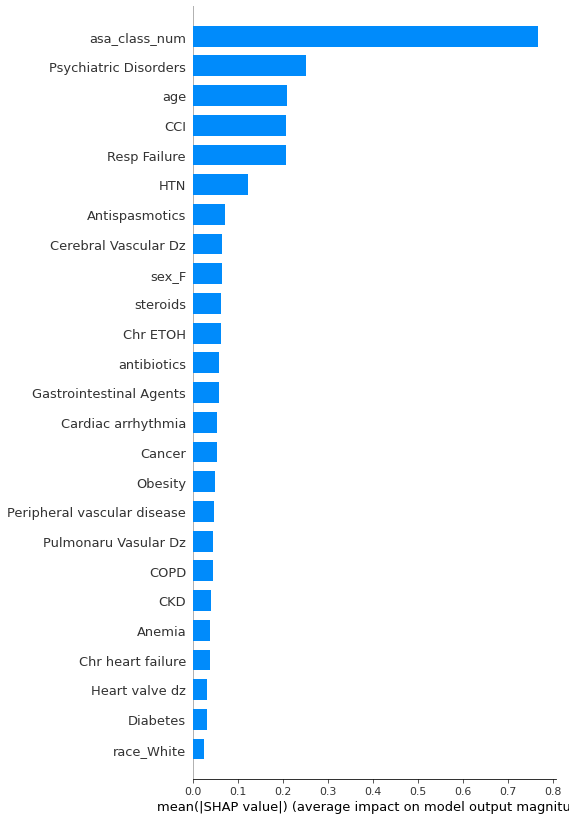

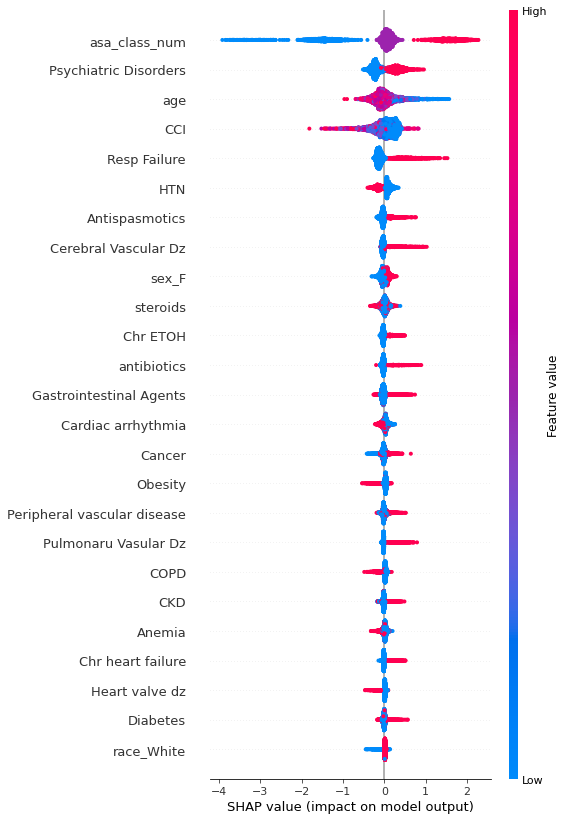

<Figure size 432x288 with 0 Axes>

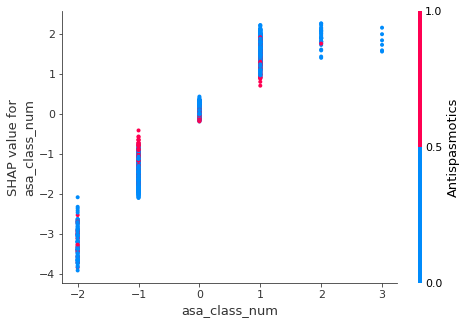

<Figure size 432x288 with 0 Axes>

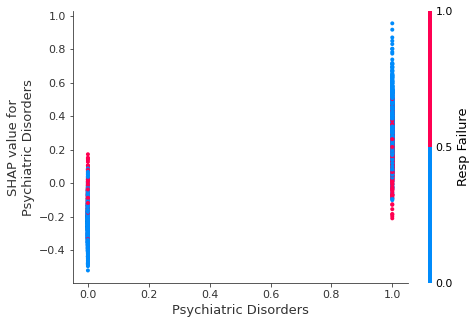

<Figure size 432x288 with 0 Axes>

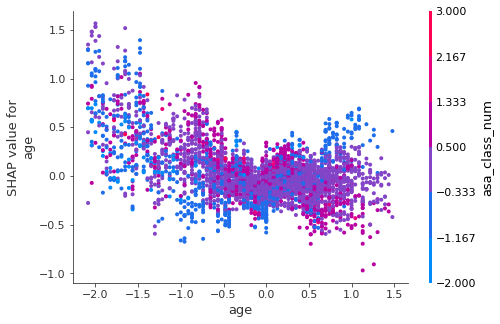

<Figure size 432x288 with 0 Axes>

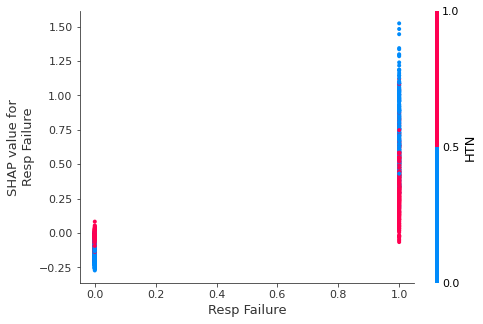

<Figure size 432x288 with 0 Axes>

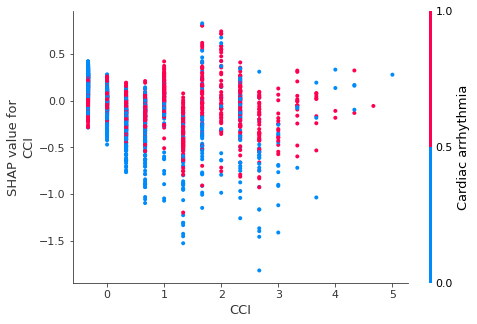

<Figure size 432x288 with 0 Axes>

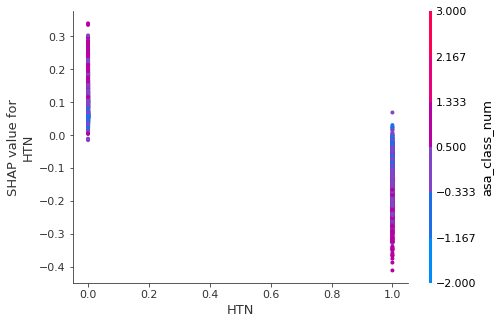


[surgery_related] Top 15 SHAP features:


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
0,duration,1.454474
3,EYE,0.285743
12,asa_emerg_flag,0.162822
8,Neurosurgery,0.110857
10,Thoracic,0.110041
9,Orthopedics,0.086996
5,GU,0.068791
7,General Surgery,0.054781
1,ENT,0.045117
11,Vascular,0.033253


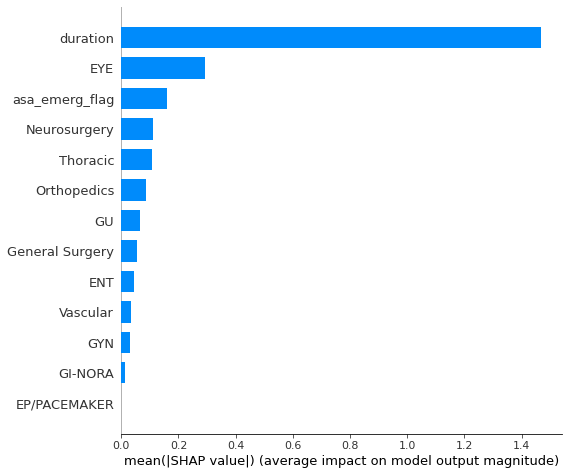

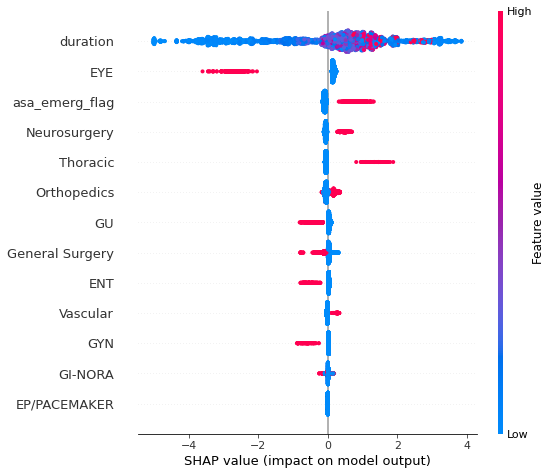

<Figure size 432x288 with 0 Axes>

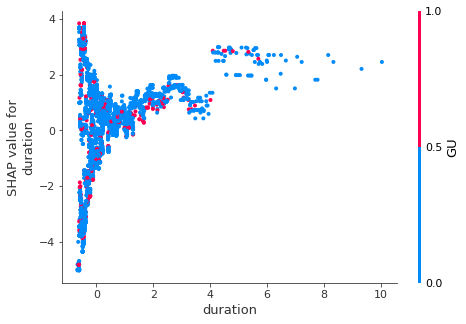

<Figure size 432x288 with 0 Axes>

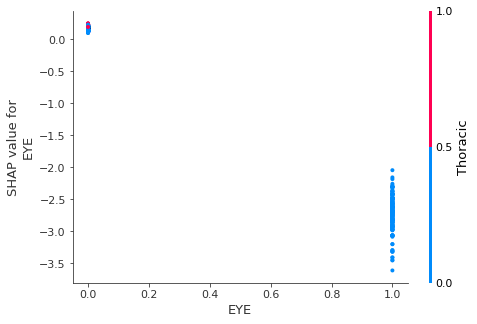

<Figure size 432x288 with 0 Axes>

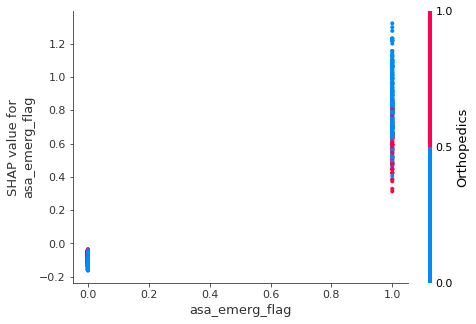

<Figure size 432x288 with 0 Axes>

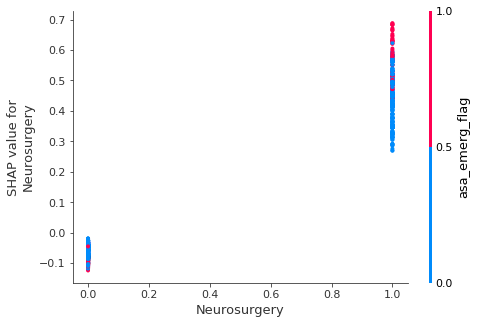

<Figure size 432x288 with 0 Axes>

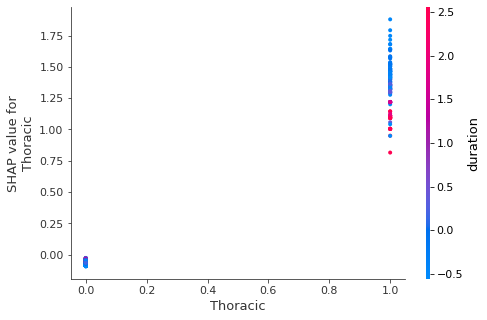

<Figure size 432x288 with 0 Axes>

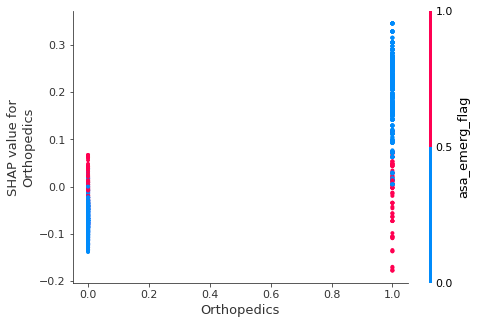


[anesthetics_related] Top 15 SHAP features:


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
0,map_65_95_min,0.406612
31,phenylephrine,0.262997
34,rocuronium,0.254899
32,propofol,0.228077
5,total_mac_hrs,0.217601
4,map_min,0.215882
1,map_gt_95_min,0.180306
2,map_lt_65_min,0.177361
3,map_max,0.149805
25,midazolam,0.111365


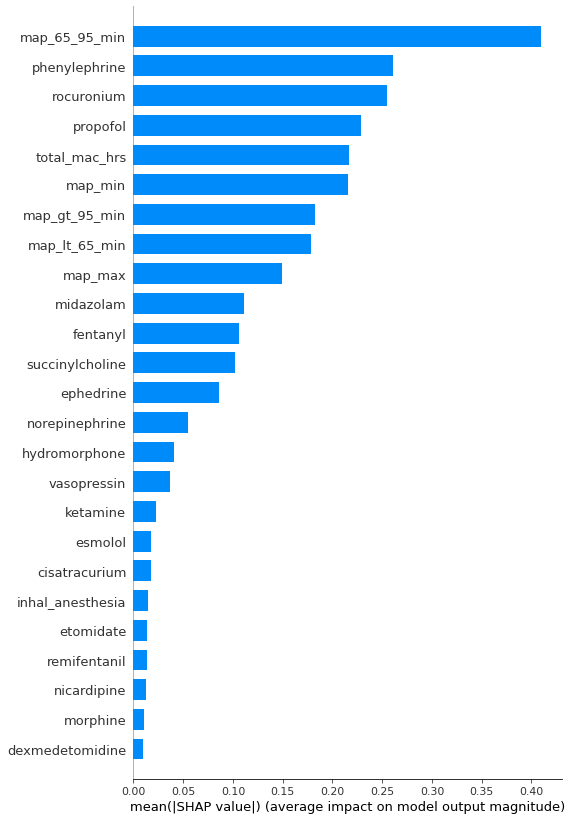

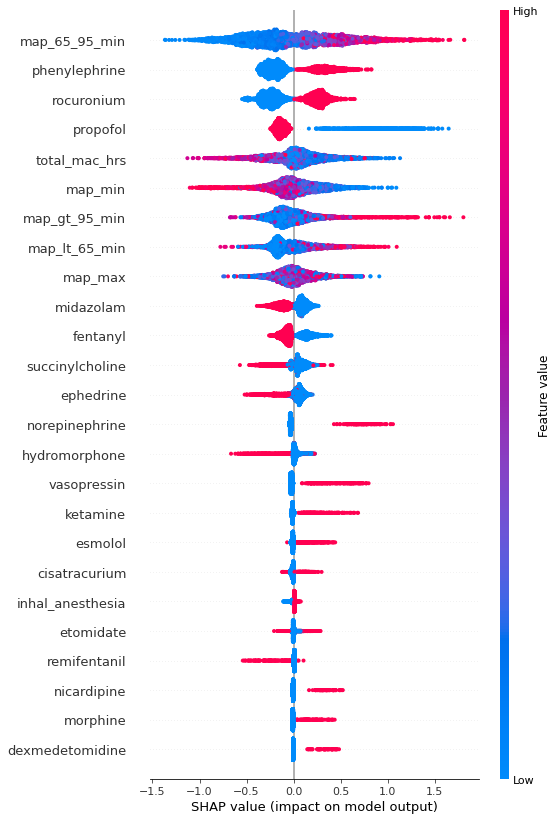

<Figure size 432x288 with 0 Axes>

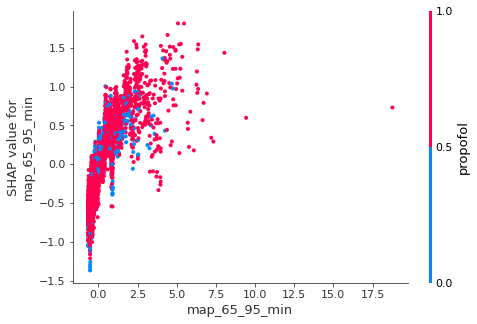

<Figure size 432x288 with 0 Axes>

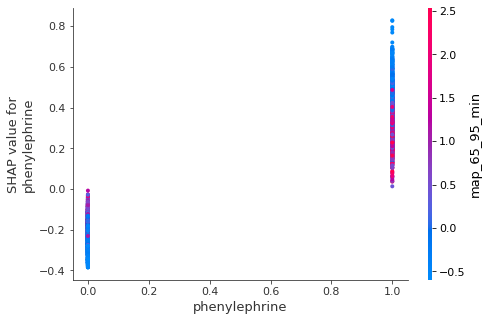

<Figure size 432x288 with 0 Axes>

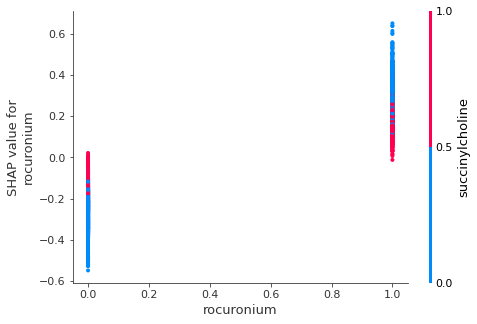

<Figure size 432x288 with 0 Axes>

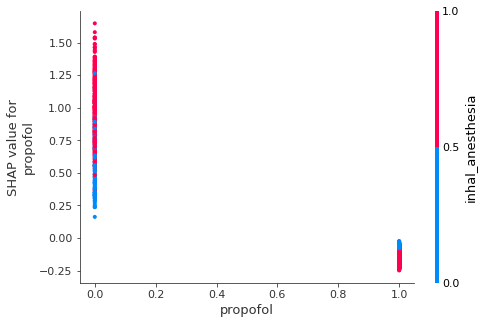

<Figure size 432x288 with 0 Axes>

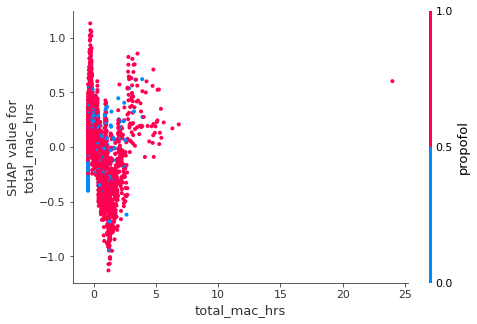

<Figure size 432x288 with 0 Axes>

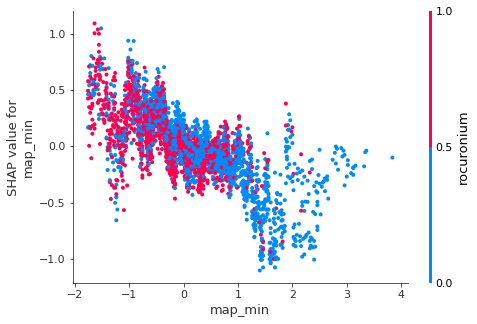


Saved per-domain SHAP artifacts to artifacts/shap/


In [22]:
# E) Per-domain feature-level SHAP (global + dependence)

import json, joblib, numpy as np, pandas as pd
import shap, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

# ---- Load schema/spec/domains ----
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)
with open("artifacts/preprocessor_spec.json", "r") as f:
    spec = json.load(f)
with open("artifacts/domains.json", "r") as f:
    domains = json.load(f)

TARGET       = schema["target"]
EXCLUDED     = set(schema.get("exclude_cols", []))
present_cont = spec["present_cont"]
present_cat  = spec["present_cat"]
present_bin  = spec["present_bin"]

# Helper: build unfitted preprocessor restricted to chosen columns
def make_preprocessor(cols_subset):
    cont = [c for c in present_cont if c in cols_subset]
    cat  = [c for c in present_cat  if c in cols_subset]
    biny = [c for c in present_bin  if c in cols_subset]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)
    cont_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale",  RobustScaler())])
    cat_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("ohe",    ohe)])
    bin_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])
    return ColumnTransformer(
        transformers=[
            ("cont", cont_pipe, cont),
            ("cat",  cat_pipe,  cat),
            ("bin",  bin_pipe,  biny),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

# Base LGBM params
lgbm_params = dict(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=-1,
    verbosity=-1,
)

# Data: drop target/IDs/admin
X_cols = [c for c in df_mod.columns if c not in EXCLUDED | {TARGET}]
y = df_mod[TARGET].astype(int).values

# Use the current domain setup by default
domains_to_explain = list(domains.keys())

outdir = Path("artifacts/shap")
outdir.mkdir(parents=True, exist_ok=True)

for dname in domains_to_explain:
    dcols = [c for c in domains[dname] if c in X_cols]
    if not dcols:
        print(f"[{dname}] No usable columns. Skipping.")
        continue

    # Fit domain pipeline on ALL data (global explanation)
    prep = make_preprocessor(dcols)
    clf  = LGBMClassifier(**lgbm_params)
    pipe = Pipeline([("prep", prep), ("clf", clf)])
    pipe.fit(df_mod[dcols], y)

    # Transform features & get feature names after preprocessing
    X_trans = pipe.named_steps["prep"].transform(df_mod[dcols])
    feat_names = pipe.named_steps["prep"].get_feature_names_out()

    # Tree SHAP
    explainer = shap.TreeExplainer(pipe.named_steps["clf"])
    sv = explainer.shap_values(X_trans)
    # LightGBM binary often returns [class0, class1]
    if isinstance(sv, list) and len(sv) == 2:
        sv = sv[1]

    # Global importance table (mean |SHAP|)
    mean_abs = np.abs(sv).mean(axis=0)
    shap_imp = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
    shap_imp.to_csv(outdir / f"{dname}_global_importance.csv", index=False)
    print(f"\n[{dname}] Top 15 SHAP features:")
    display(shap_imp.head(15))

    # Convert sparse to dense for plotting only if needed (sample if huge)
    X_plot = X_trans
    if hasattr(X_plot, "toarray"):
        # Sample up to 4000 rows to keep RAM reasonable for plots
        idx = np.random.RandomState(42).choice(X_plot.shape[0], size=min(4000, X_plot.shape[0]), replace=False)
        X_plot = X_plot[idx].toarray()
        sv_plot = sv[idx]
    else:
        idx = np.random.RandomState(42).choice(X_plot.shape[0], size=min(4000, X_plot.shape[0]), replace=False)
        X_plot = X_plot[idx]
        sv_plot = sv[idx]

    # Global plots
    plt.figure(figsize=(8,5))
    shap.summary_plot(sv_plot, X_plot, feature_names=feat_names, plot_type="bar", show=True, max_display=25)
    plt.title(f"{dname} — SHAP global importance")
    plt.tight_layout()
    plt.savefig(outdir / f"{dname}_bar.png", dpi=200)
    plt.close()

    plt.figure(figsize=(9,6))
    shap.summary_plot(sv_plot, X_plot, feature_names=feat_names, show=True, max_display=25)
    plt.title(f"{dname} — SHAP beeswarm")
    plt.tight_layout()
    plt.savefig(outdir / f"{dname}_beeswarm.png", dpi=200)
    plt.close()

    # Dependence plots for the top 6 features (with interaction suggestion)
    top_feats = shap_imp["feature"].head(6).tolist()
    for f in top_feats:
        plt.figure(figsize=(6,4))
        try:
            shap.dependence_plot(f, sv_plot, X_plot, feature_names=feat_names, show=True, interaction_index="auto")
        except Exception:
            # Fallback: manual scatter if anything odd occurs
            j = list(feat_names).index(f)
            vals = X_plot[:, j]
            plt.scatter(vals, sv_plot[:, j], s=6, alpha=0.4)
            plt.xlabel(f); plt.ylabel("SHAP value")
        plt.title(f"{dname} — SHAP dependence: {f}")
        plt.tight_layout()
        plt.savefig(outdir / f"{dname}_depend_{f.replace('/','_')}.png", dpi=200)
        plt.close()

    # Save fitted domain pipeline in case we need per-domain predictions later
    joblib.dump(pipe, outdir / f"{dname}_pipeline.joblib")

print("\nSaved per-domain SHAP artifacts to artifacts/shap/")


# Calibration + ROC for META-LEARNER

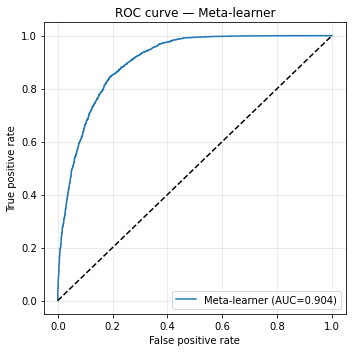

Saved ROC plot → artifacts/plots/roc_meta_learner.png


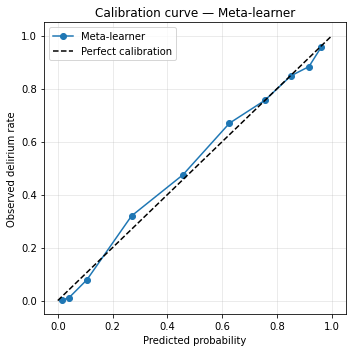

Saved calibration plot → artifacts/plots/calibration_meta_learner.png


In [23]:
# D2) Calibration + ROC for META-LEARNER

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, roc_auc_score

# Load true labels
y = df_mod["del_1"].astype(int).values

# Load meta-learner OOF probabilities
meta_oof = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values

# Make output folder
plot_dir = "artifacts/plots"
os.makedirs(plot_dir, exist_ok=True)

# ROC curve
fpr, tpr, _ = roc_curve(y, meta_oof)
auc_val = roc_auc_score(y, meta_oof)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"Meta-learner (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve — Meta-learner")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

fname = os.path.join(plot_dir, "roc_meta_learner.png")
plt.savefig(fname, dpi=200)
plt.show()

print(f"Saved ROC plot → {fname}")


# Calibration curve
frac_pos, mean_pred = calibration_curve(y, meta_oof, n_bins=10, strategy="quantile")

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, "o-", label="Meta-learner")
plt.plot([0,1],[0,1],"k--", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed delirium rate")
plt.title("Calibration curve — Meta-learner")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()

fname = os.path.join(plot_dir, "calibration_meta_learner.png")
plt.savefig(fname, dpi=200)
plt.show()

print(f"Saved calibration plot → {fname}")


# Decision Curve Analysis (DCA) for meta-learner

Sample prevalence of delirium: 0.500


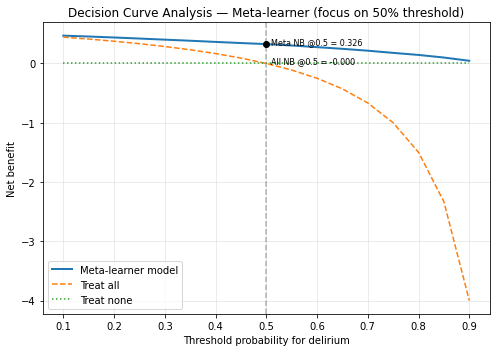

DCA plot saved → artifacts/plots/dca_meta_learner_50pct.png


In [24]:
# D3) Decision Curve Analysis (DCA) for meta-learner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# True labels and meta-learner OOF probabilities
y = df_mod["del_1"].astype(int).values
meta_oof = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values

N = len(y)
prevalence = y.mean()
print(f"Sample prevalence of delirium: {prevalence:.3f}")

# Decision thresholds (include 0.5 explicitly)
thresholds = np.linspace(0.1, 0.9, 17)  # 0.1, 0.15, ..., 0.9
if 0.5 not in thresholds:
    thresholds = np.sort(np.append(thresholds, 0.5))

nb_none = np.zeros_like(thresholds)  # net benefit of treating none is 0

nb_all = []
nb_meta = []

for p_t in thresholds:
    # Model
    preds = (meta_oof >= p_t).astype(int)
    TP = np.sum((preds == 1) & (y == 1))
    FP = np.sum((preds == 1) & (y == 0))

    tp_rate = TP / N
    fp_rate = FP / N

    w = p_t / (1 - p_t)  # odds at threshold
    nb_m = tp_rate - w * fp_rate
    nb_meta.append(nb_m)

    # Treat all
    TP_all = np.sum(y == 1)
    FP_all = np.sum(y == 0)
    tp_all = TP_all / N
    fp_all = FP_all / N
    nb_a = tp_all - w * fp_all
    nb_all.append(nb_a)

nb_all = np.array(nb_all)
nb_meta = np.array(nb_meta)

# Plot DCA
os.makedirs("artifacts/plots", exist_ok=True)

plt.figure(figsize=(7,5))
plt.plot(thresholds, nb_meta, label="Meta-learner model", linewidth=2)
plt.plot(thresholds, nb_all, label="Treat all", linestyle="--")
plt.plot(thresholds, nb_none, label="Treat none", linestyle=":")

# Highlight threshold = 0.5
t_star = 0.5
if t_star >= thresholds.min() and t_star <= thresholds.max():
    # interpolate net benefit at 0.5 for model and all
    nb_meta_star = np.interp(t_star, thresholds, nb_meta)
    nb_all_star  = np.interp(t_star, thresholds, nb_all)
    plt.axvline(t_star, color="grey", linestyle="--", alpha=0.6)
    plt.scatter([t_star], [nb_meta_star], color="black", zorder=5)
    plt.text(t_star+0.01, nb_meta_star, f"Meta NB @0.5 = {nb_meta_star:.3f}", fontsize=8)
    plt.text(t_star+0.01, nb_all_star,  f"All NB @0.5 = {nb_all_star:.3f}", fontsize=8)

plt.xlabel("Threshold probability for delirium")
plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis — Meta-learner (focus on 50% threshold)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()

fname = "artifacts/plots/dca_meta_learner_50pct.png"
plt.savefig(fname, dpi=200)
plt.show()

print(f"DCA plot saved → {fname}")


In [ ]:
# End of Notebook